# Final EDA And Model Comparison

This notebook runs the final capstone EDA and model comparison for football player market value prediction.

- Input: `data/processed/player_season_analytics.csv`
- Target: `log_market_value_eur`
- Minimum minutes filter: `Min >= 300`
- Train seasons: `21/22`, `22/23`
- Test season: `23/24`
- Models: mean baseline, linear regression, ridge regression, hist-gradient boosting


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "analysis"))

import eda_and_baseline as capstone

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

MIN_MINUTES = 300
INCLUDE_POSITION_MODELS = True


## Load Data And Run EDA

The EDA step regenerates missingness tables, distribution plots, group summaries, and correlation outputs.

In [2]:
capstone.ensure_dirs()
df = capstone.load_data(capstone.DEFAULT_INPUT)
eda_stats = capstone.run_eda(df, min_minutes=MIN_MINUTES)
model_df = capstone.make_modeling_dataset(df, min_minutes=MIN_MINUTES)

overview = pd.DataFrame(
    [
        {"metric": "source_rows", "value": len(df)},
        {"metric": "source_columns", "value": len(df.columns)},
        {"metric": "modeling_rows", "value": len(model_df)},
        {"metric": "train_rows", "value": model_df["season"].isin(capstone.TRAIN_SEASONS).sum()},
        {"metric": "test_rows", "value": model_df["season"].isin(capstone.TEST_SEASONS).sum()},
        {"metric": "rows_under_300_minutes", "value": eda_stats["rows_under_min_minutes"]},
        {"metric": "missing_contract_rows", "value": eda_stats["contract_missing_rows"]},
    ]
)
overview


,metric,value
0,source_rows,6471
1,source_columns,84
2,modeling_rows,5658
3,train_rows,3818
4,test_rows,1840
5,rows_under_300_minutes,813
6,missing_contract_rows,321


In [3]:
display(model_df["season"].value_counts().rename_axis("season").reset_index(name="rows"))
display(model_df["position_group"].value_counts().rename_axis("position_group").reset_index(name="rows"))
display(model_df["cleaned_comp"].value_counts().rename_axis("league").reset_index(name="rows"))


,season,rows
0,21/22,1919
1,22/23,1899
2,23/24,1840


,position_group,rows
0,MF,2443
1,DF,1614
2,FW,1601


,league,rows
0,Premier League,1181
1,Serie A,1180
2,La Liga,1166
3,Ligue 1,1124
4,Bundesliga,1007


## Global And Position-Specific Models

The global model comparison uses the full `300+` minute modeling dataset. Position-specific models are trained separately for defenders, midfielders, and forwards as diagnostic comparisons.

In [4]:
metrics, predictions, fitted_models = capstone.run_models(
    model_df,
    include_position_models=INCLUDE_POSITION_MODELS,
)
feature_importance = capstone.save_feature_importance(fitted_models, model_df)
best_global_model = (
    metrics[(metrics["scope"] == "global") & (metrics["split"] == "test")]
    .sort_values("rmse_log")
    .iloc[0]["model"]
)
error_by_group = capstone.save_error_by_group(predictions, best_global_model)
capstone.plot_model_diagnostics(metrics, predictions, best_global_model)
capstone.write_summary(eda_stats, model_df, metrics, feature_importance, min_minutes=MIN_MINUTES)
capstone.write_final_report(
    eda_stats,
    model_df,
    metrics,
    error_by_group,
    feature_importance,
    min_minutes=MIN_MINUTES,
)
capstone.write_paper_sources(min_minutes=MIN_MINUTES)

global_test_metrics = (
    metrics[(metrics["scope"] == "global") & (metrics["split"] == "test")]
    .sort_values("rmse_log")
    .reset_index(drop=True)
)
global_test_metrics


,scope,position_group,model,split,rows,rmse_log,mae_log,r2,rmse_eur,mae_eur
0,global,ALL,hist_gradient_boosting,test,1840,0.8877,0.6663,0.6146,"13,332,965.4513","6,871,178.1624"
1,global,ALL,ridge_alpha_1,test,1840,0.9925,0.7341,0.5183,"16,920,261.6928","7,665,130.2120"
2,global,ALL,linear_regression,test,1840,0.9925,0.7341,0.5183,"16,967,897.3933","7,668,460.5645"
3,global,ALL,mean_baseline,test,1840,1.4320,1.1333,-0.0027,"21,474,722.9580","11,046,357.1685"


In [5]:
position_test_metrics = (
    metrics[(metrics["scope"] == "position_specific") & (metrics["split"] == "test")]
    .sort_values(["position_group", "rmse_log"])
    .reset_index(drop=True)
)
position_test_metrics


,scope,position_group,model,split,rows,rmse_log,mae_log,r2,rmse_eur,mae_eur
0,position_specific,DF,hist_gradient_boosting,test,529,1.0218,0.7499,0.4826,"11,046,652.2639","6,338,351.1081"
1,position_specific,DF,ridge_alpha_1,test,529,1.0279,0.7672,0.4765,"11,664,518.4267","6,496,404.2608"
2,position_specific,DF,linear_regression,test,529,1.0311,0.7705,0.4731,"11,680,614.4192","6,527,717.2685"
3,position_specific,DF,mean_baseline,test,529,1.4314,1.1577,-0.0153,"15,821,636.2131","9,276,864.3312"
4,position_specific,FW,hist_gradient_boosting,test,507,0.8695,0.6652,0.6352,"16,058,991.0464","8,330,176.1533"
5,position_specific,FW,linear_regression,test,507,0.9348,0.6865,0.5784,"20,623,828.6993","9,252,821.7791"
6,position_specific,FW,ridge_alpha_1,test,507,0.9350,0.6867,0.5782,"20,739,043.9961","9,267,816.3604"
7,position_specific,FW,mean_baseline,test,507,1.4400,1.1490,-0.0005,"27,158,845.4617","13,996,184.8491"
8,position_specific,MF,hist_gradient_boosting,test,804,0.9360,0.7041,0.5636,"13,238,264.5892","6,805,028.6565"
9,position_specific,MF,ridge_alpha_1,test,804,0.9999,0.7353,0.5019,"13,895,523.4160","6,981,802.5153"


## Feature Importance And Error Diagnostics

Ridge coefficients are useful as a standardized linear check. Permutation importance summarizes which original input columns most affect the best nonlinear model on the held-out season.

In [6]:
top_hgb_features = feature_importance[
    (feature_importance["model"] == "hist_gradient_boosting")
    & (feature_importance["importance_type"] == "permutation_rmse_drop")
].head(12)
top_hgb_features[["feature", "importance", "importance_std"]]


,feature,importance,importance_std
29,Age,0.1845,0.0141
30,contract_years_remaining,0.1497,0.0167
31,cleaned_comp,0.1464,0.0075
32,contract_missing,0.1301,0.0117
33,transfer_count_before_valuation,0.1123,0.0090
34,crosses_per90,0.0435,0.0063
35,days_since_last_transfer,0.0383,0.0057
36,goals_per90,0.0379,0.0039
37,90s,0.0378,0.0079
38,assists_per90,0.0335,0.0058


In [7]:
error_by_group.sort_values(["group_column", "mae_log"])[
    ["group_column", "group_value", "rows", "mae_log", "rmse_log", "mae_eur"]
].reset_index(drop=True)


,group_column,group_value,rows,mae_log,rmse_log,mae_eur
0,cleaned_comp,Premier League,393,0.6186,0.8815,"10,498,859.8927"
1,cleaned_comp,Serie A,391,0.6325,0.8256,"5,350,644.1297"
2,cleaned_comp,Ligue 1,341,0.6821,0.8677,"5,086,252.7112"
3,cleaned_comp,Bundesliga,326,0.6889,0.8687,"6,427,194.5320"
4,cleaned_comp,La Liga,389,0.7156,0.9824,"6,671,301.8879"
5,position_group,FW,507,0.6271,0.8022,"8,081,882.9584"
6,position_group,MF,804,0.6692,0.8938,"6,607,319.0532"
7,position_group,DF,529,0.6994,0.9539,"6,111,849.9814"
8,season,23/24,1840,0.6663,0.8877,"6,871,178.1624"


## Generated Figures

reports\figures\market_value_distribution.png


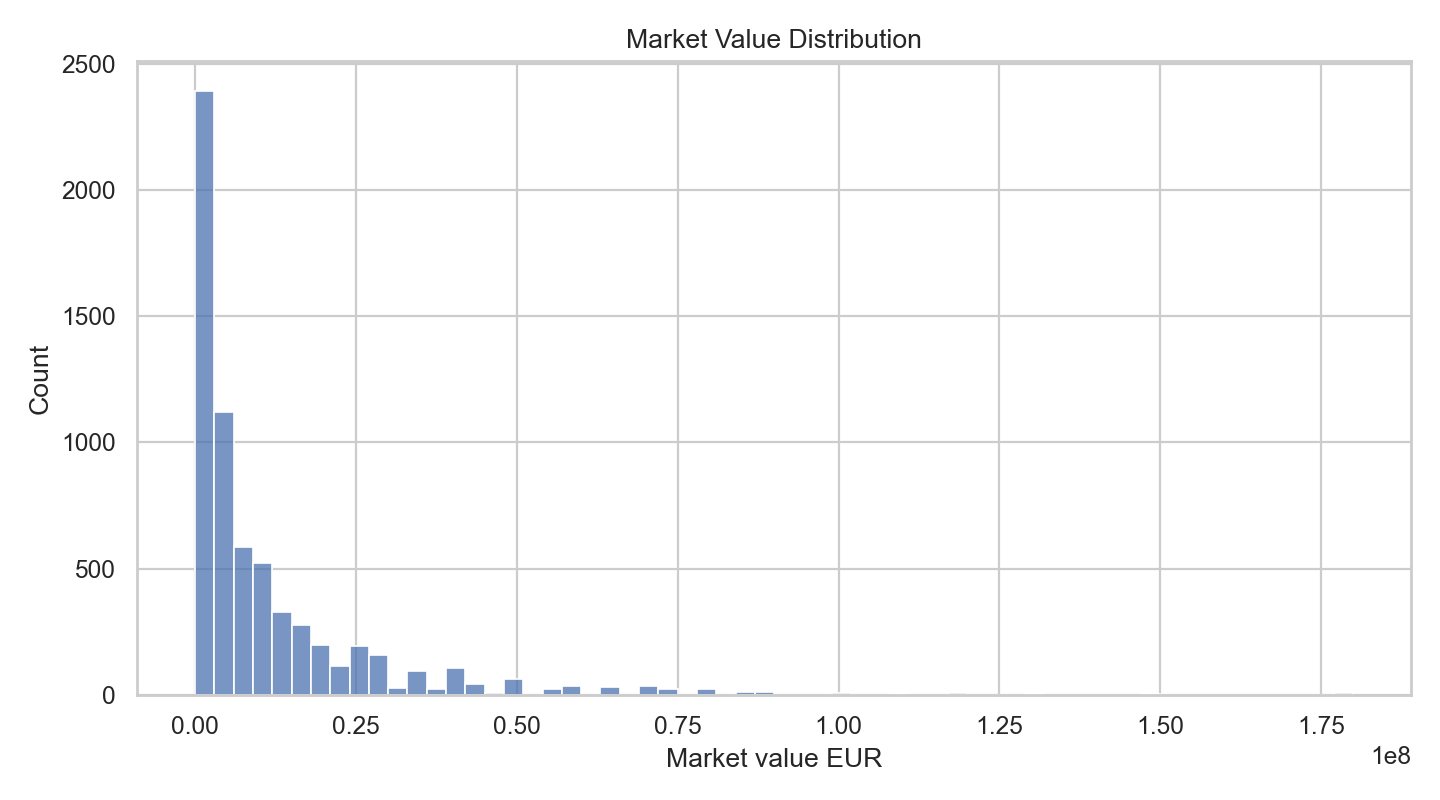

reports\figures\log_market_value_distribution.png


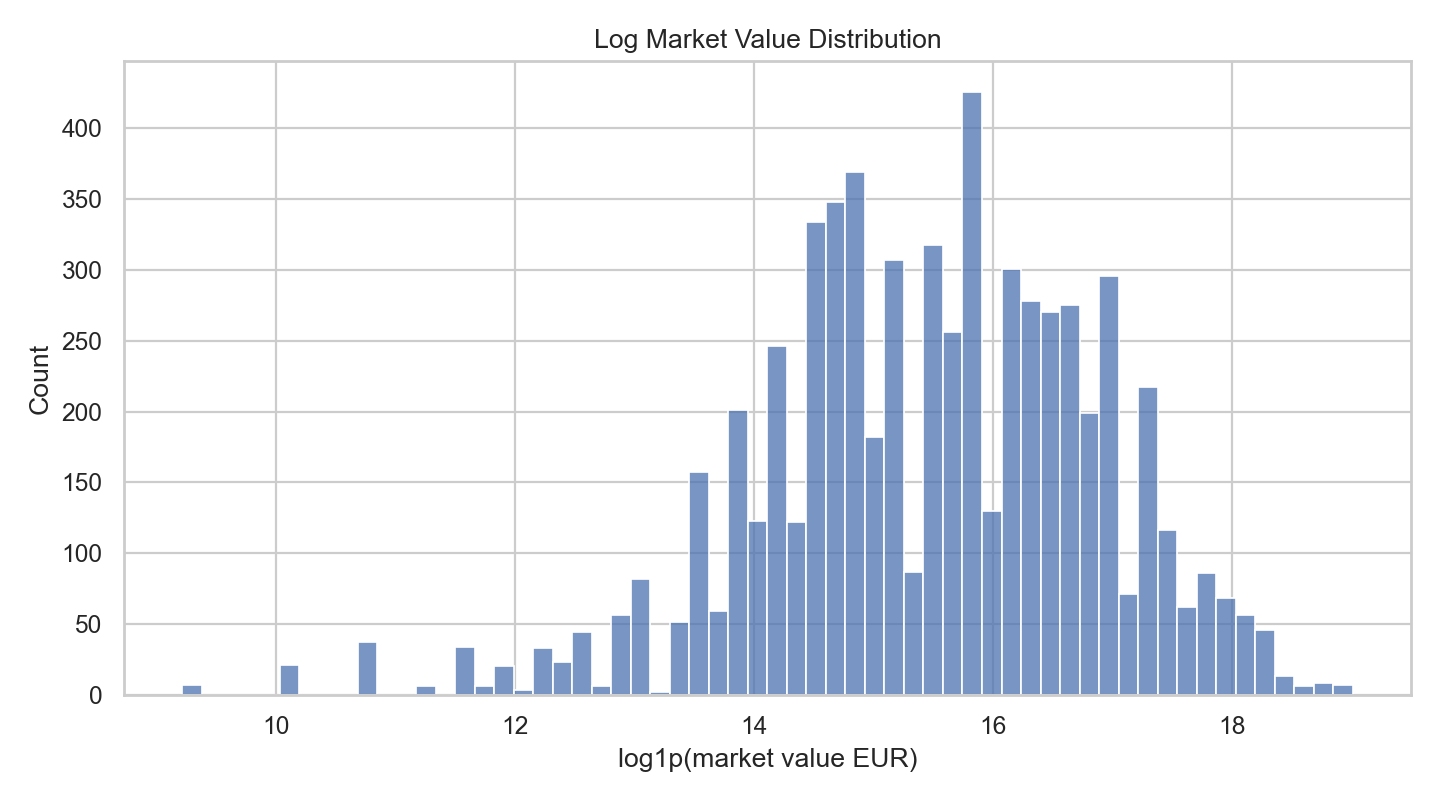

reports\figures\log_market_value_by_league.png


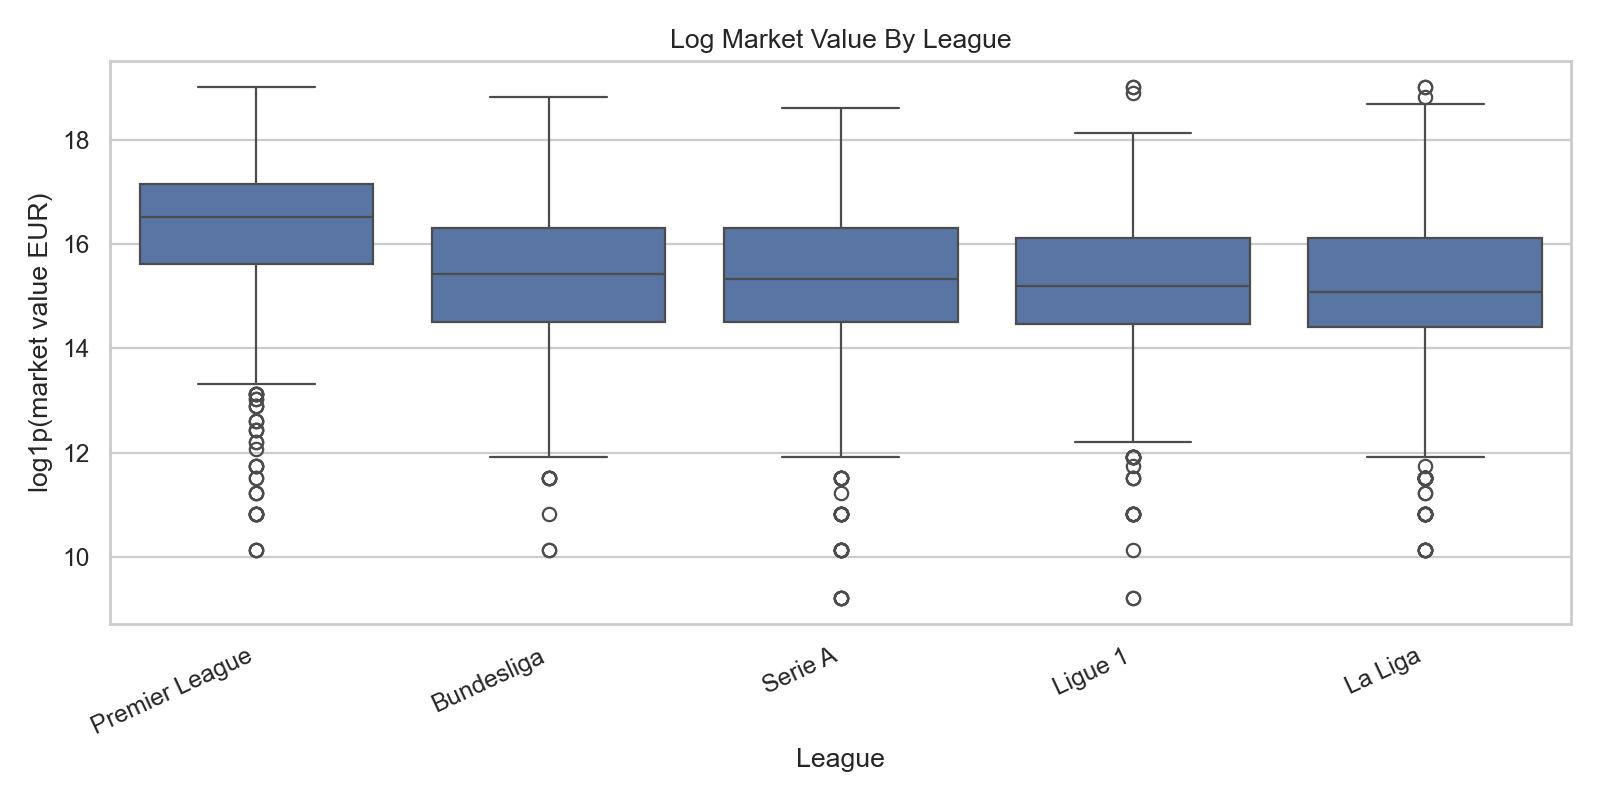

reports\figures\log_market_value_by_position.png


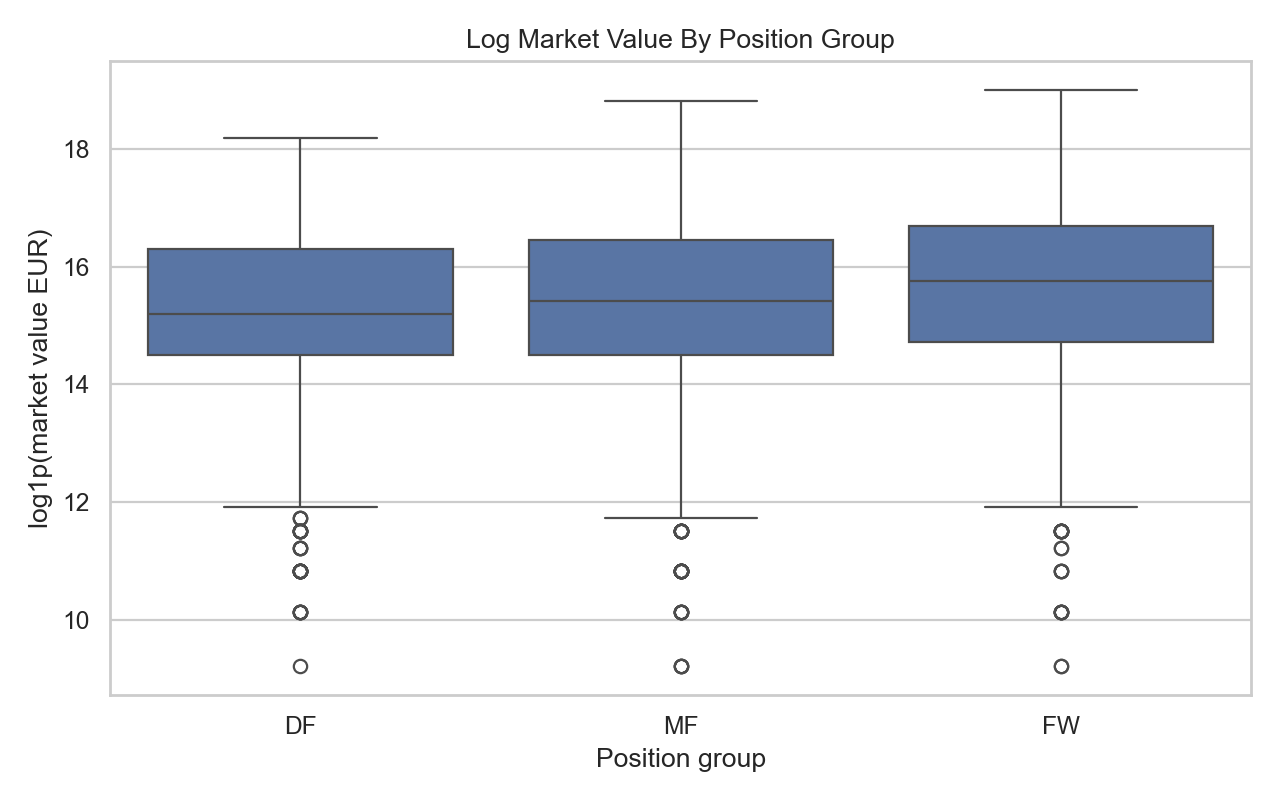

reports\figures\contract_years_vs_log_market_value.png


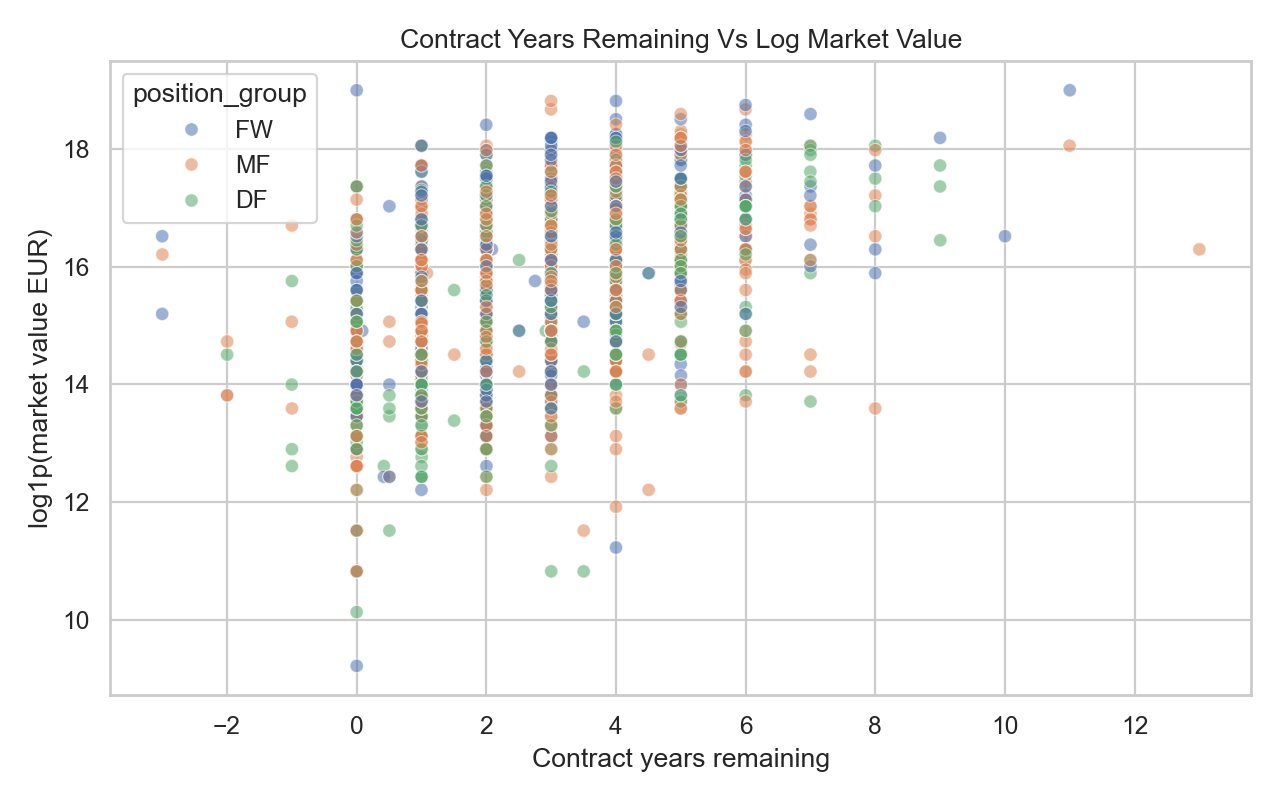

reports\figures\numeric_correlation_heatmap.png


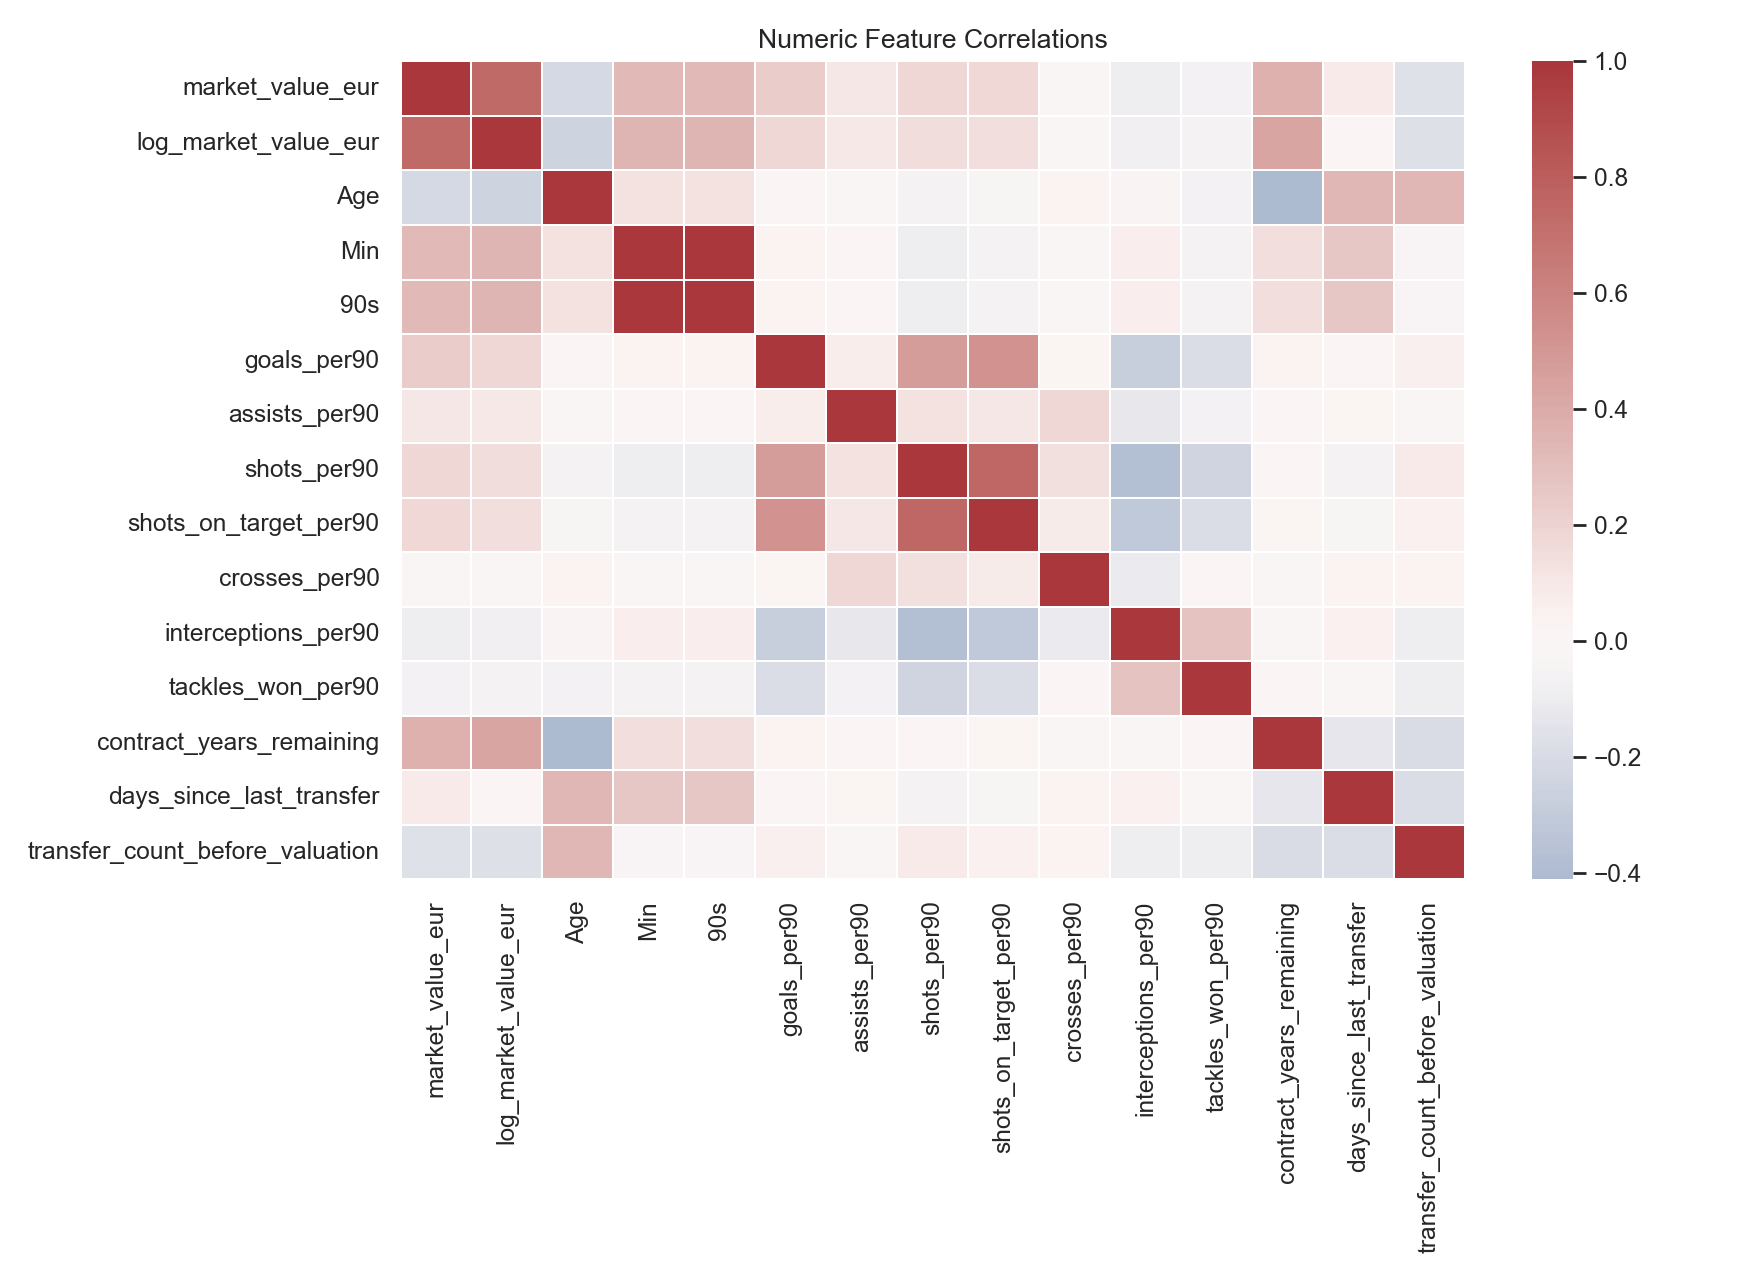

reports\figures\model_comparison_test_rmse.png


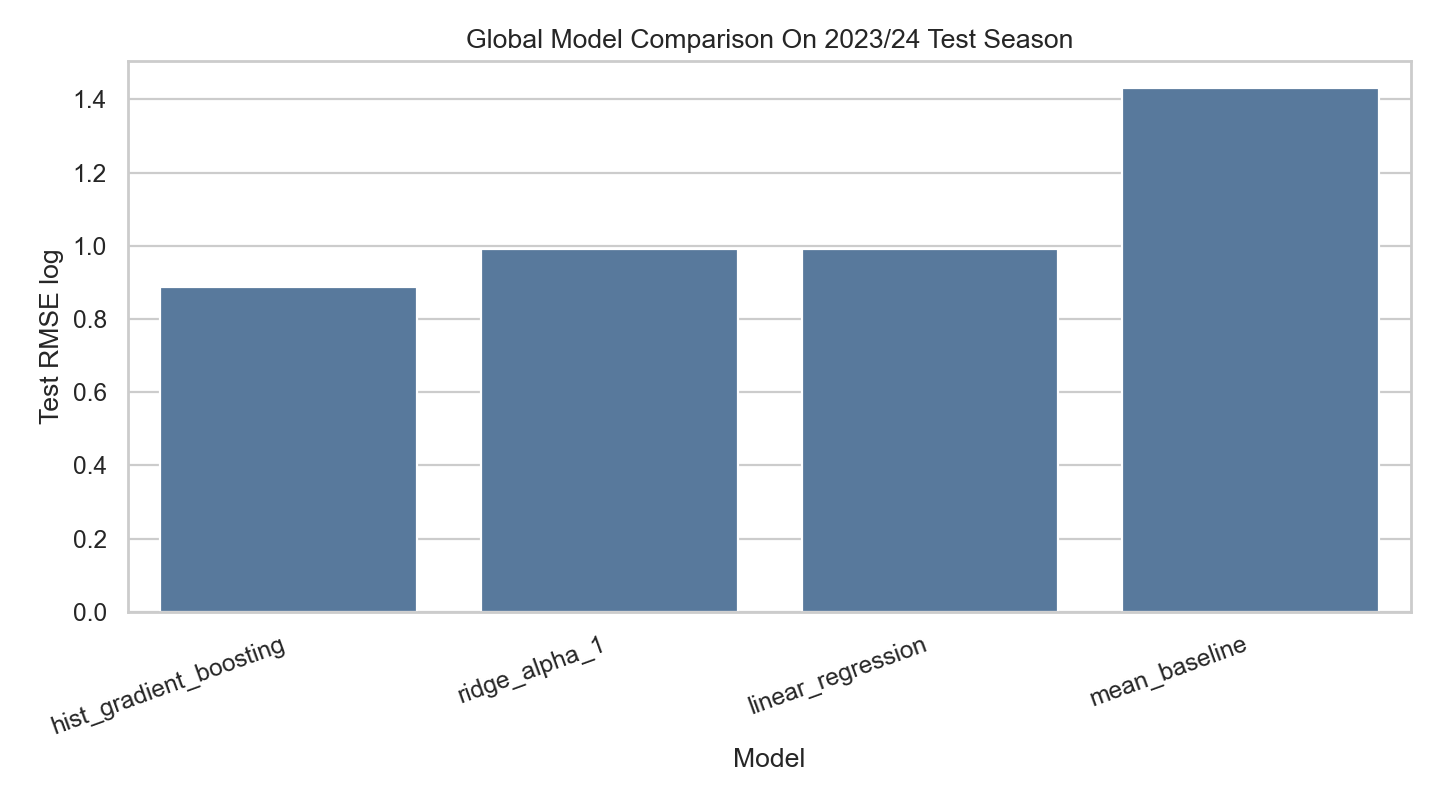

reports\figures\predicted_vs_actual_best_model.png


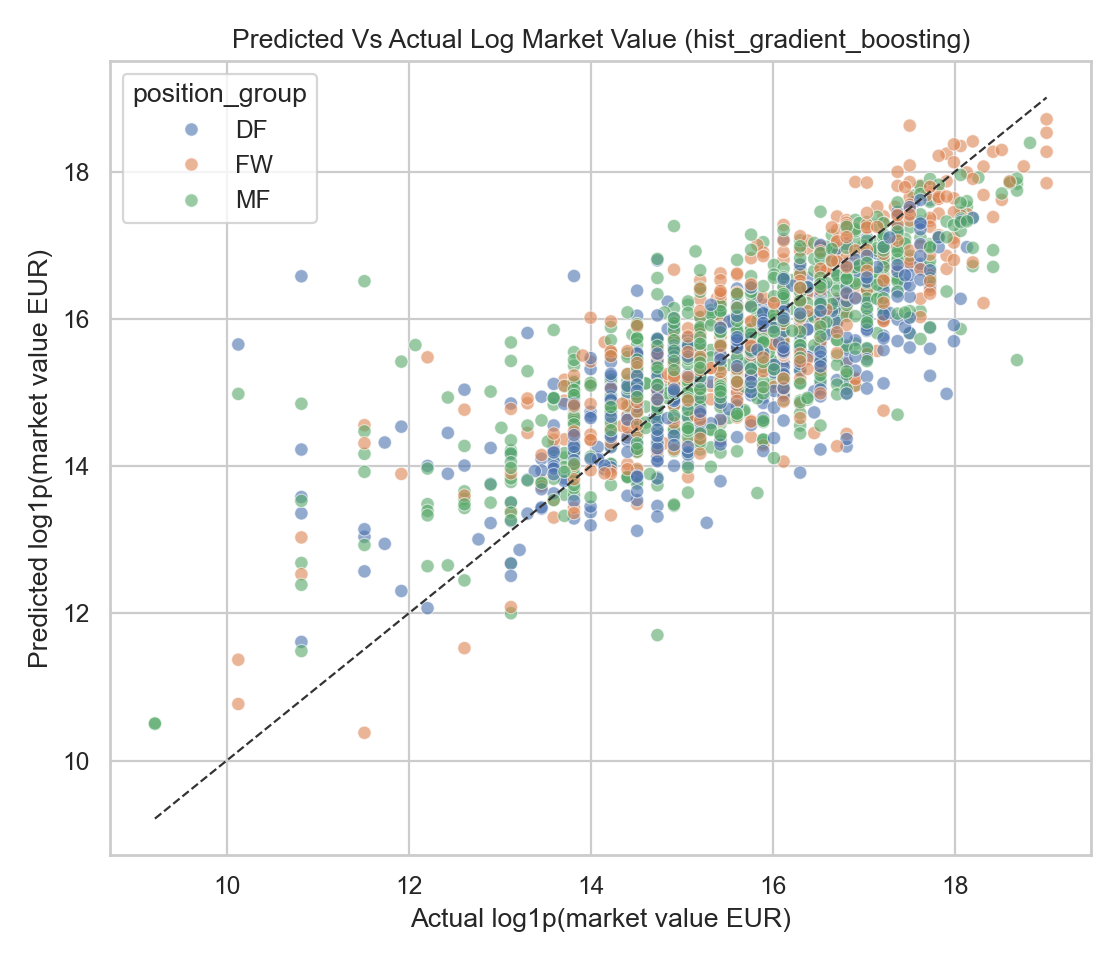

reports\figures\residuals_by_league_position.png


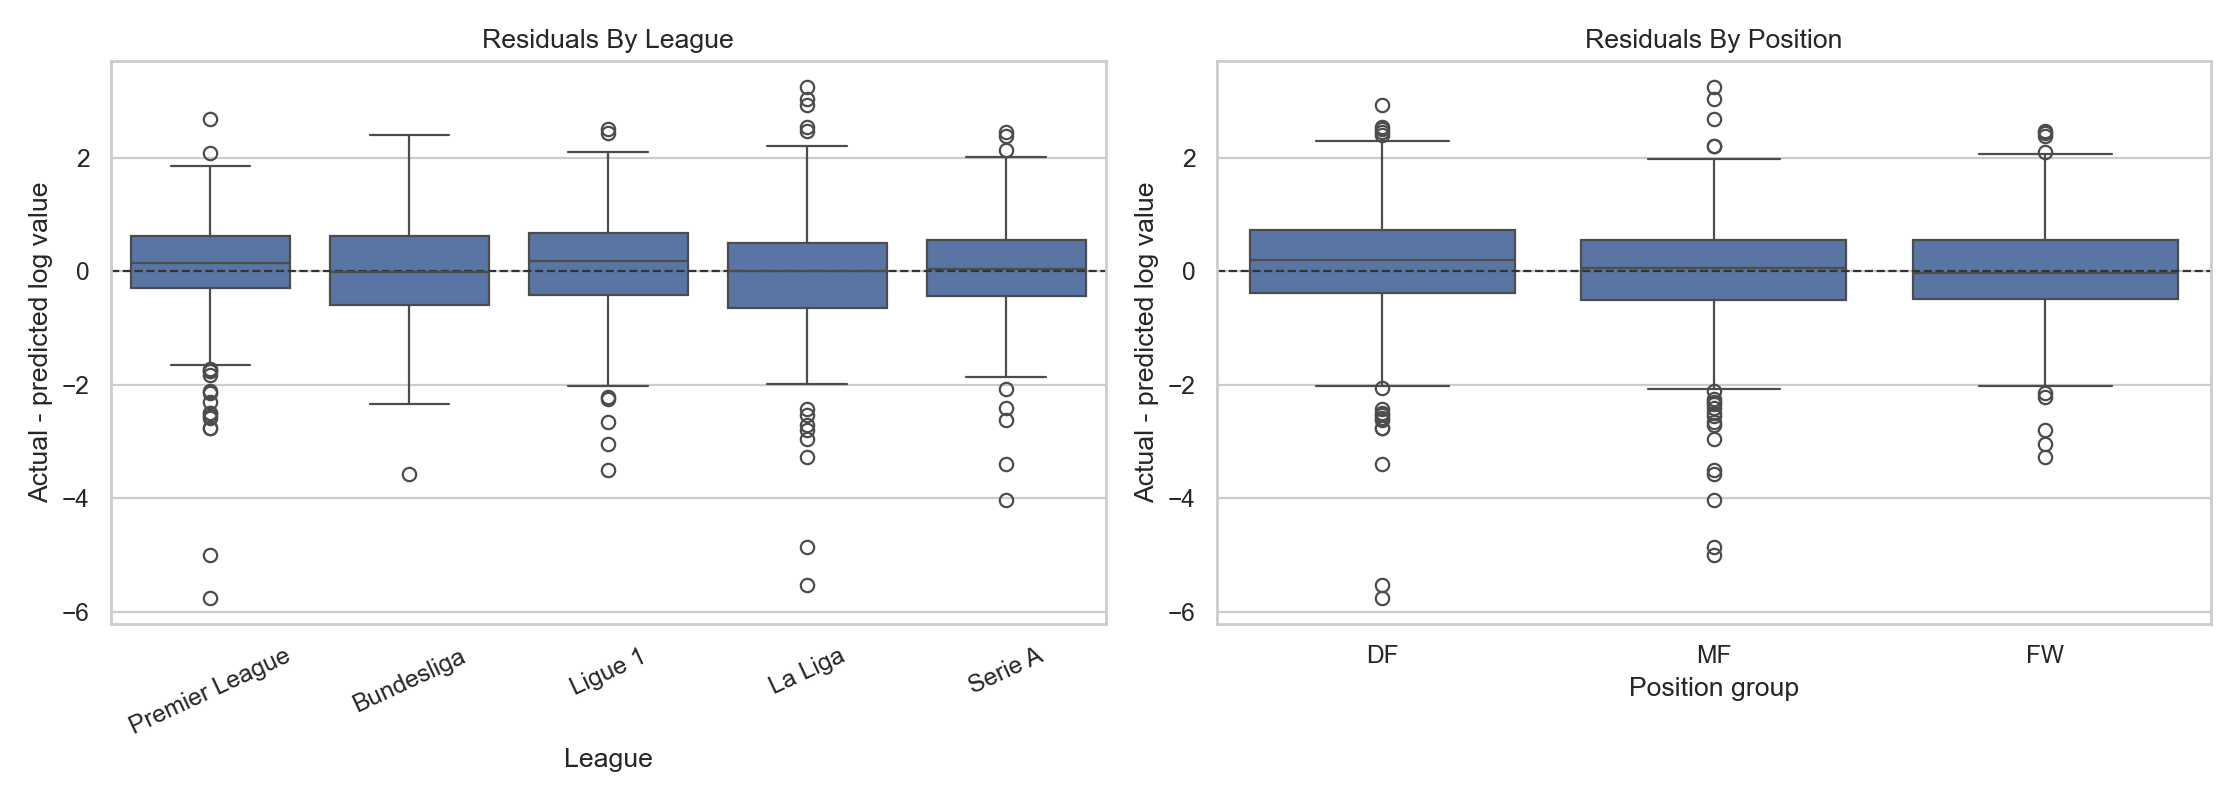

reports\figures\position_model_comparison.png


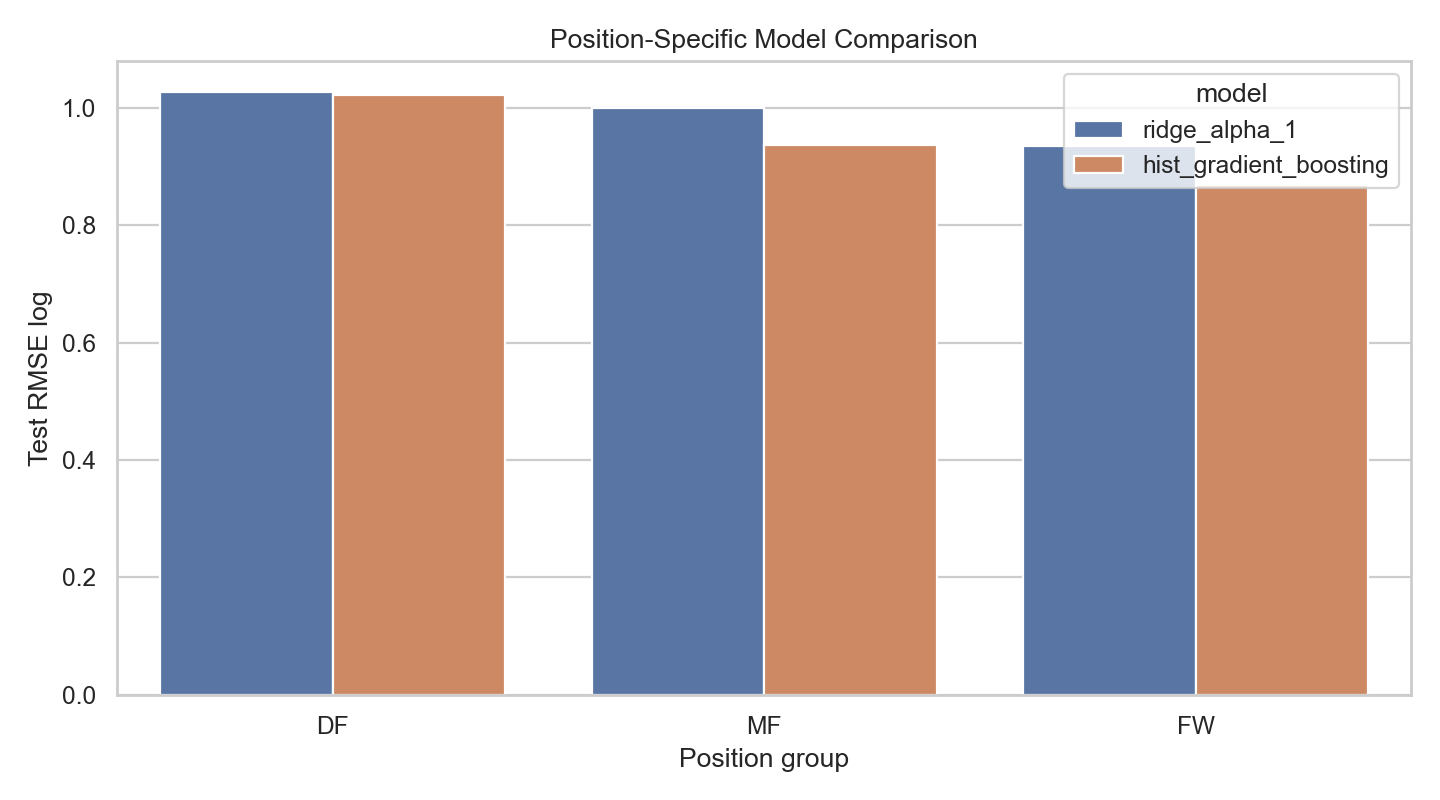

In [8]:
figure_names = [
    "market_value_distribution.png",
    "log_market_value_distribution.png",
    "log_market_value_by_league.png",
    "log_market_value_by_position.png",
    "contract_years_vs_log_market_value.png",
    "numeric_correlation_heatmap.png",
    "model_comparison_test_rmse.png",
    "predicted_vs_actual_best_model.png",
    "residuals_by_league_position.png",
    "position_model_comparison.png",
]

for figure_name in figure_names:
    path = capstone.FIGURES_DIR / figure_name
    print(path.relative_to(REPO_ROOT))
    display(Image(filename=str(path)))


## Final Takeaways

- The `Min >= 300` filter keeps `5,658` modeling rows, compared with `4,228` under the earlier `900+` minute setup.
- The hist-gradient boosting model is the best global model on the held-out `23/24` test season.
- The final global benchmark is approximately `0.888` test RMSE log and `0.615` test R2.
- The larger sample gives better player coverage, but low-minute observations are noisier than regular-starter observations.
- Age, minutes, contract years remaining, league, and position remain important valuation signals.
- The notebook regenerates `reports/final_report.md`, `paper/main.tex`, and all report tables/figures from code.
